# PCB Defect Detection: Preprocessing

Build a deterministic, detection-ready copy of the existing DeepPCB splits. The raw images and source annotations remain unchanged. The current first-training candidate is a 512×512 direct resize with bbox coordinates transformed in lockstep; the original 640×640 copy remains available under `Data/processed/none_640` as an accuracy reference. Letterbox remains available for non-square inputs. Random augmentation is excluded and belongs in the training pipeline.

Outputs are written to a mode-specific folder under `Data/processed/`: processed images, per-split YOLO labels, a canonical pixel-coordinate CSV, a class mapping, an image manifest, and train-derived pixel normalization statistics.

In [11]:
import json
import os
import platform
import shutil
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

RANDOM_SEED = 42
SPATIAL_MODE = "resize"
TARGET_SIZE = 512
PAD_VALUE = 114

WORKSPACE_ROOT = Path.cwd().resolve()
DATA_ROOT = Path(os.environ.get(
    "PCB_DATA_ROOT", WORKSPACE_ROOT / "Data" / "raw_data"
)).expanduser().resolve()
TARGETS_CSV = Path(os.environ.get(
    "PCB_TARGETS_CSV", DATA_ROOT.parent / "derived" / "stage2_targets.csv"
)).expanduser().resolve()
CLASS_MAPPING_CSV = Path(os.environ.get(
    "PCB_CLASS_MAPPING_CSV", DATA_ROOT.parent / "derived" / "class_mapping.csv"
)).expanduser().resolve()
OUTPUT_BASE = Path(os.environ.get(
    "PCB_PROCESSED_ROOT", DATA_ROOT.parent / "processed"
)).expanduser().resolve()
OUTPUT_ROOT = OUTPUT_BASE / f"{SPATIAL_MODE}_{TARGET_SIZE}"

SUPPORTED_SPATIAL_MODES = {"none", "resize", "letterbox"}
if SPATIAL_MODE not in SUPPORTED_SPATIAL_MODES:
    raise ValueError(f"SPATIAL_MODE must be one of {sorted(SUPPORTED_SPATIAL_MODES)}")
if TARGET_SIZE < 1:
    raise ValueError("TARGET_SIZE must be positive")
if not DATA_ROOT.is_dir():
    raise FileNotFoundError(f"Data root not found: {DATA_ROOT}")
if not TARGETS_CSV.is_file():
    raise FileNotFoundError(f"Canonical targets CSV not found: {TARGETS_CSV}")
if not CLASS_MAPPING_CSV.is_file():
    raise FileNotFoundError(f"Class mapping CSV not found: {CLASS_MAPPING_CSV}")
if OUTPUT_ROOT == DATA_ROOT or DATA_ROOT in OUTPUT_ROOT.parents:
    raise ValueError("Output root must not be inside the raw-data root")


def display_path(path):
    resolved_path = Path(path).expanduser().resolve()
    try:
        return resolved_path.relative_to(WORKSPACE_ROOT).as_posix()
    except ValueError:
        return f"<external>/{resolved_path.name}"


package_versions = {"python": platform.python_version()}
for distribution in ("numpy", "pandas", "Pillow", "matplotlib"):
    try:
        package_versions[distribution] = version(distribution)
    except PackageNotFoundError:
        package_versions[distribution] = "not installed"

print(f"Data root: {display_path(DATA_ROOT)}")
print(f"Canonical targets: {display_path(TARGETS_CSV)}")
print(f"Output root: {display_path(OUTPUT_ROOT)}")
print(f"Spatial mode: {SPATIAL_MODE} | target size: {TARGET_SIZE} | seed: {RANDOM_SEED}")
display(pd.Series(package_versions, name="version").to_frame())

Data root: Data/raw_data
Canonical targets: Data/derived/stage2_targets.csv
Output root: Data/processed/resize_512
Spatial mode: resize | target size: 512 | seed: 42


,version
python,3.13.5
numpy,2.1.3
pandas,2.3.2
Pillow,11.1.0
matplotlib,3.10.6


## 1. Nạp và kiểm tra nguồn

Tái sử dụng `stage2_targets.csv` và `class_mapping.csv` từ bước Data Understanding. Tạo manifest từ các thư mục ảnh thực tế, không chỉ từ annotation, để ảnh không có bbox (nếu có) vẫn được giữ lại. Kiểm tra khả năng decode ảnh, kích thước, class mapping và bbox trước khi xuất.

In [12]:
TARGET_COLUMNS = {
    "split", "image_name", "class_id", "class_index", "class_name",
    "x1", "y1", "x2", "y2", "image_width", "image_height",
}
CLASS_COLUMNS = {"class_id", "class_index", "class_name"}
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

class_mapping = pd.read_csv(CLASS_MAPPING_CSV)
if not CLASS_COLUMNS.issubset(class_mapping.columns):
    raise ValueError(f"Class mapping is missing columns: {sorted(CLASS_COLUMNS - set(class_mapping.columns))}")
class_mapping = class_mapping.sort_values("class_index").reset_index(drop=True)
if class_mapping["class_index"].tolist() != list(range(len(class_mapping))):
    raise ValueError("class_index values must be contiguous and start at zero")
if class_mapping["class_id"].duplicated().any() or class_mapping["class_name"].duplicated().any():
    raise ValueError("Class IDs and names must each be unique")
CLASS_NAMES = class_mapping["class_name"].astype(str).tolist()
CLASS_ID_TO_INDEX = dict(zip(class_mapping["class_id"].astype(int), class_mapping["class_index"].astype(int)))

source_targets = pd.read_csv(TARGETS_CSV)
if not TARGET_COLUMNS.issubset(source_targets.columns):
    raise ValueError(f"Targets CSV is missing columns: {sorted(TARGET_COLUMNS - set(source_targets.columns))}")
source_targets = source_targets.copy()
for column in ("class_id", "class_index", "x1", "y1", "x2", "y2", "image_width", "image_height"):
    source_targets[column] = pd.to_numeric(source_targets[column], errors="raise")
if not np.isfinite(source_targets[[
    "class_id", "class_index", "x1", "y1", "x2", "y2", "image_width", "image_height"
]].to_numpy(dtype=float)).all():
    raise ValueError("Canonical targets contain non-finite numeric values")

split_roots = {
    path.name: path
    for path in DATA_ROOT.iterdir()
    if path.is_dir() and (path / "images").is_dir()
}
SPLITS = tuple(sorted(
    split_roots,
    key=lambda split: (("train", "valid", "test").index(split)
                       if split in ("train", "valid", "test") else 3, split),
))
if set(source_targets["split"].unique()) != set(SPLITS):
    raise ValueError(
        f"Target splits {sorted(source_targets['split'].unique())} do not match image splits {list(SPLITS)}"
    )

image_rows = []
image_path_by_key = {}
for split in SPLITS:
    images_dir = split_roots[split] / "images"
    paths = sorted(
        path for path in images_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES
    )
    for image_path in paths:
        with Image.open(image_path) as source:
            source.load()
            image_width, image_height = source.size
            source_mode = source.mode
        image_key = (split, image_path.name)
        if image_key in image_path_by_key:
            raise ValueError(f"Duplicate image key: {image_key}")
        image_path_by_key[image_key] = image_path
        image_rows.append({
            "split": split,
            "image_name": image_path.name,
            "image_path": image_path,
            "source_width": image_width,
            "source_height": image_height,
            "source_mode": source_mode,
            "source_bytes": image_path.stat().st_size,
        })
image_manifest = pd.DataFrame(image_rows)
if image_manifest.empty:
    raise ValueError(f"No readable images found under {DATA_ROOT}")

image_keys = set(image_path_by_key)
target_keys = set(zip(source_targets["split"], source_targets["image_name"]))
missing_images = sorted(target_keys - image_keys)
if missing_images:
    raise FileNotFoundError(f"Target rows refer to missing images: {missing_images[:10]}")

expected_class_indices = source_targets["class_id"].map(CLASS_ID_TO_INDEX)
if expected_class_indices.isna().any():
    raise ValueError("Targets contain class IDs absent from the class mapping")
if not np.array_equal(
    expected_class_indices.to_numpy(dtype=int),
    source_targets["class_index"].to_numpy(dtype=int),
):
    raise ValueError("class_id and class_index do not agree with the class mapping")
expected_class_names = source_targets["class_index"].astype(int).map(dict(enumerate(CLASS_NAMES)))
if not expected_class_names.equals(source_targets["class_name"].astype(str)):
    raise ValueError("class_index and class_name do not agree with the class mapping")

image_dimensions = image_manifest.set_index(["split", "image_name"])[
    ["source_width", "source_height"]
]
target_dimensions = source_targets.set_index(["split", "image_name"])[
    ["image_width", "image_height"]
]
joined_dimensions = target_dimensions.join(image_dimensions, how="left")
if not joined_dimensions["source_width"].eq(joined_dimensions["image_width"]).all():
    raise ValueError("Target image_width values disagree with the actual image files")
if not joined_dimensions["source_height"].eq(joined_dimensions["image_height"]).all():
    raise ValueError("Target image_height values disagree with the actual image files")

coordinate_columns = ["x1", "y1", "x2", "y2"]
coordinate_values = source_targets[coordinate_columns].to_numpy(dtype=float)
if not np.equal(coordinate_values, np.floor(coordinate_values)).all():
    raise ValueError("Pixel-coordinate boxes must contain integer-valued coordinates")
valid_boxes = (
    source_targets["x1"].ge(0)
    & source_targets["y1"].ge(0)
    & source_targets["x2"].gt(source_targets["x1"])
    & source_targets["y2"].gt(source_targets["y1"])
    & source_targets["x2"].le(source_targets["image_width"])
    & source_targets["y2"].le(source_targets["image_height"])
)
if not valid_boxes.all():
    raise ValueError(f"Invalid or out-of-bounds boxes: {int((~valid_boxes).sum())}")
if source_targets.duplicated(["split", "image_name", "class_id", "x1", "y1", "x2", "y2"]).any():
    raise ValueError("Duplicate annotation rows found")

box_counts = source_targets.groupby(["split", "image_name"]).size()
image_manifest["num_boxes"] = [
    int(box_counts.get((row.split, row.image_name), 0))
    for row in image_manifest.itertuples()
]
unannotated_images = image_manifest.loc[
    image_manifest["num_boxes"] == 0, ["split", "image_name"]
]

print(f"Images decoded: {len(image_manifest):,} | annotation rows: {len(source_targets):,}")
print(f"Valid boxes: {int(valid_boxes.sum()):,} | images with no boxes retained: {len(unannotated_images):,}")
print("Image counts and source modes by split:")
display(image_manifest.groupby("split").agg(
    images=("image_name", "size"),
    boxes=("num_boxes", "sum"),
    mean_boxes_per_image=("num_boxes", "mean"),
).reindex(SPLITS).round(3))
if not unannotated_images.empty:
    display(unannotated_images.head(20))
print("Source image modes:")
display(image_manifest["source_mode"].value_counts().rename("images").to_frame())

Images decoded: 1,500 | annotation rows: 10,013
Valid boxes: 10,013 | images with no boxes retained: 0
Image counts and source modes by split:


,images,boxes,mean_boxes_per_image
split,,,
train,1200,8024,6.687
valid,150,1005,6.700
test,150,984,6.560


Source image modes:


,images
source_mode,
L,1462
RGB,38


## 2. Biến đổi ảnh và bbox

`none/640` giữ nguyên pixel gốc và là reference; cấu hình export hiện tại chọn `resize/512` cho lượt train đầu. Ảnh gốc đều vuông nên resize vuông không đổi aspect ratio. `letterbox` vẫn có sẵn cho nguồn không vuông. Mọi mode đều cập nhật bbox cùng phép biến đổi ảnh; file biến đổi được lưu PNG. RGB và scale `[0,1]` được tạo nhất quán; không crop bbox thành mẫu train và không augment validation/test.

In [13]:
def transform_boxes(boxes, scale_x, scale_y, offset_x=0.0, offset_y=0.0, output_width=None, output_height=None):
    transformed = []
    for box in boxes:
        x1 = box["x1"] * scale_x + offset_x
        y1 = box["y1"] * scale_y + offset_y
        x2 = box["x2"] * scale_x + offset_x
        y2 = box["y2"] * scale_y + offset_y
        if output_width is not None:
            x1 = min(max(x1, 0.0), float(output_width))
            x2 = min(max(x2, 0.0), float(output_width))
        if output_height is not None:
            y1 = min(max(y1, 0.0), float(output_height))
            y2 = min(max(y2, 0.0), float(output_height))
        if x2 <= x1 or y2 <= y1:
            raise ValueError(f"Spatial transform collapsed box: {box}")
        transformed.append({
            **box,
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
        })
    return transformed


def preprocess_image_and_boxes(image_path, boxes, spatial_mode=SPATIAL_MODE, target_size=TARGET_SIZE):
    if spatial_mode not in SUPPORTED_SPATIAL_MODES:
        raise ValueError(f"Unsupported spatial mode: {spatial_mode}")
    if target_size < 1:
        raise ValueError("target_size must be positive")

    with Image.open(image_path) as source:
        image = source.convert("RGB")
    source_width, source_height = image.size
    if spatial_mode == "none":
        return image.copy(), transform_boxes(boxes, 1.0, 1.0), {
            "source_width": source_width,
            "source_height": source_height,
            "output_width": source_width,
            "output_height": source_height,
            "scale_x": 1.0,
            "scale_y": 1.0,
            "offset_x": 0.0,
            "offset_y": 0.0,
        }

    if spatial_mode == "resize":
        output_size = (target_size, target_size)
        resized = image.resize(output_size, Image.Resampling.BILINEAR)
        scale_x = target_size / source_width
        scale_y = target_size / source_height
        transformed = transform_boxes(
            boxes, scale_x, scale_y,
            output_width=target_size, output_height=target_size,
        )
        return resized, transformed, {
            "source_width": source_width,
            "source_height": source_height,
            "output_width": target_size,
            "output_height": target_size,
            "scale_x": scale_x,
            "scale_y": scale_y,
            "offset_x": 0.0,
            "offset_y": 0.0,
        }

    scale = min(target_size / source_width, target_size / source_height)
    resized_width = max(1, int(round(source_width * scale)))
    resized_height = max(1, int(round(source_height * scale)))
    resized = image.resize((resized_width, resized_height), Image.Resampling.BILINEAR)
    offset_x = (target_size - resized_width) // 2
    offset_y = (target_size - resized_height) // 2
    canvas = Image.new("RGB", (target_size, target_size), (PAD_VALUE,) * 3)
    canvas.paste(resized, (offset_x, offset_y))
    scale_x = resized_width / source_width
    scale_y = resized_height / source_height
    transformed = transform_boxes(
        boxes, scale_x, scale_y, offset_x, offset_y,
        output_width=target_size, output_height=target_size,
    )
    return canvas, transformed, {
        "source_width": source_width,
        "source_height": source_height,
        "output_width": target_size,
        "output_height": target_size,
        "scale_x": scale_x,
        "scale_y": scale_y,
        "offset_x": float(offset_x),
        "offset_y": float(offset_y),
    }


def image_to_float01(image):
    rgb_array = np.asarray(image.convert("RGB"), dtype=np.float32)
    return rgb_array / 255.0


sample_image_row = image_manifest.iloc[0]
sample_boxes = source_targets.loc[
    (source_targets["split"] == sample_image_row["split"])
    & (source_targets["image_name"] == sample_image_row["image_name"])
].to_dict("records")
transform_smoke_tests = []
for mode in ("none", "resize", "letterbox"):
    transformed_image, transformed_boxes, transform_metadata = preprocess_image_and_boxes(
        sample_image_row["image_path"], sample_boxes, spatial_mode=mode, target_size=416
    )
    if len(transformed_boxes) != len(sample_boxes):
        raise ValueError(f"{mode} changed the number of boxes")
    if any(
        box["x1"] < 0 or box["y1"] < 0
        or box["x2"] > transform_metadata["output_width"]
        or box["y2"] > transform_metadata["output_height"]
        for box in transformed_boxes
    ):
        raise ValueError(f"{mode} produced a box outside the transformed image")
    float_image = image_to_float01(transformed_image)
    if float_image.ndim != 3 or float_image.shape[2] != 3 or not np.isfinite(float_image).all():
        raise ValueError(f"{mode} did not produce finite HWC RGB floats")
    transform_smoke_tests.append({
        "mode": mode,
        "output_size": transformed_image.size,
        "boxes_preserved": len(transformed_boxes),
        "float_min": float(float_image.min()),
        "float_max": float(float_image.max()),
    })
display(pd.DataFrame(transform_smoke_tests))

,mode,output_size,boxes_preserved,float_min,float_max
0,none,"(640, 640)",10,0.0,1.0
1,resize,"(416, 416)",10,0.0,1.0
2,letterbox,"(416, 416)",10,0.0,1.0


## 2a. Size audit sebelum model training

Đây là kiểm tra hình học/pixel và chi phí preprocessing, không dự đoán AP. So sánh 640/512/416/320 trên toàn bộ bbox; overlay crop chỉ để quan sát chi tiết. Chốt size cuối cùng cần detector validation metrics, nhất là recall/AP của box nhỏ.

Dataset-only size audit. Feature-stride columns describe sampling grid, not detector AP.


,input_size,p05_box_w_px,p05_box_h_px,median_box_w_px,median_box_h_px,p05_box_w_cells_s8,p05_box_h_cells_s8,pct_boxes_min_side_lt_8px,pct_boxes_min_side_lt_16px,one_image_float32_mib,pixels_vs_640_pct
0,640,27.00,25.00,35.00,33.00,3.38,3.12,0.0,0.00,4.69,100.00
1,512,21.60,20.00,28.00,26.40,2.70,2.50,0.0,0.02,3.00,64.00
2,416,17.55,16.25,22.75,21.45,2.19,2.03,0.0,4.09,1.98,42.25
3,320,13.50,12.50,17.50,16.50,1.69,1.56,0.0,55.69,1.17,25.00


Per-class fraction with minimum bbox side below 8 pixels:


input_size: percent < 8 px,320,416,512,640
class_name,,,,
open,0.0,0.0,0.0,0.0
short,0.0,0.0,0.0,0.0
mousebite,0.0,0.0,0.0,0.0
spur,0.0,0.0,0.0,0.0
copper,0.0,0.0,0.0,0.0
pin-hole,0.0,0.0,0.0,0.0


Per-class fraction with minimum bbox side below 16 pixels:


input_size: percent < 16 px,320,416,512,640
class_name,,,,
open,45.1,2.6,0.1,0.0
short,56.4,6.6,0.0,0.0
mousebite,70.3,5.7,0.0,0.0
spur,62.4,2.3,0.0,0.0
copper,36.5,1.7,0.1,0.0
pin-hole,61.1,5.7,0.0,0.0


CPU decode + preprocessing time on a fixed random image sample; not model inference latency:


,input_size,images_timed,decode_transform_ms_per_image
0,640,48,6.56
1,512,48,12.85
2,416,48,10.55
3,320,48,9.94


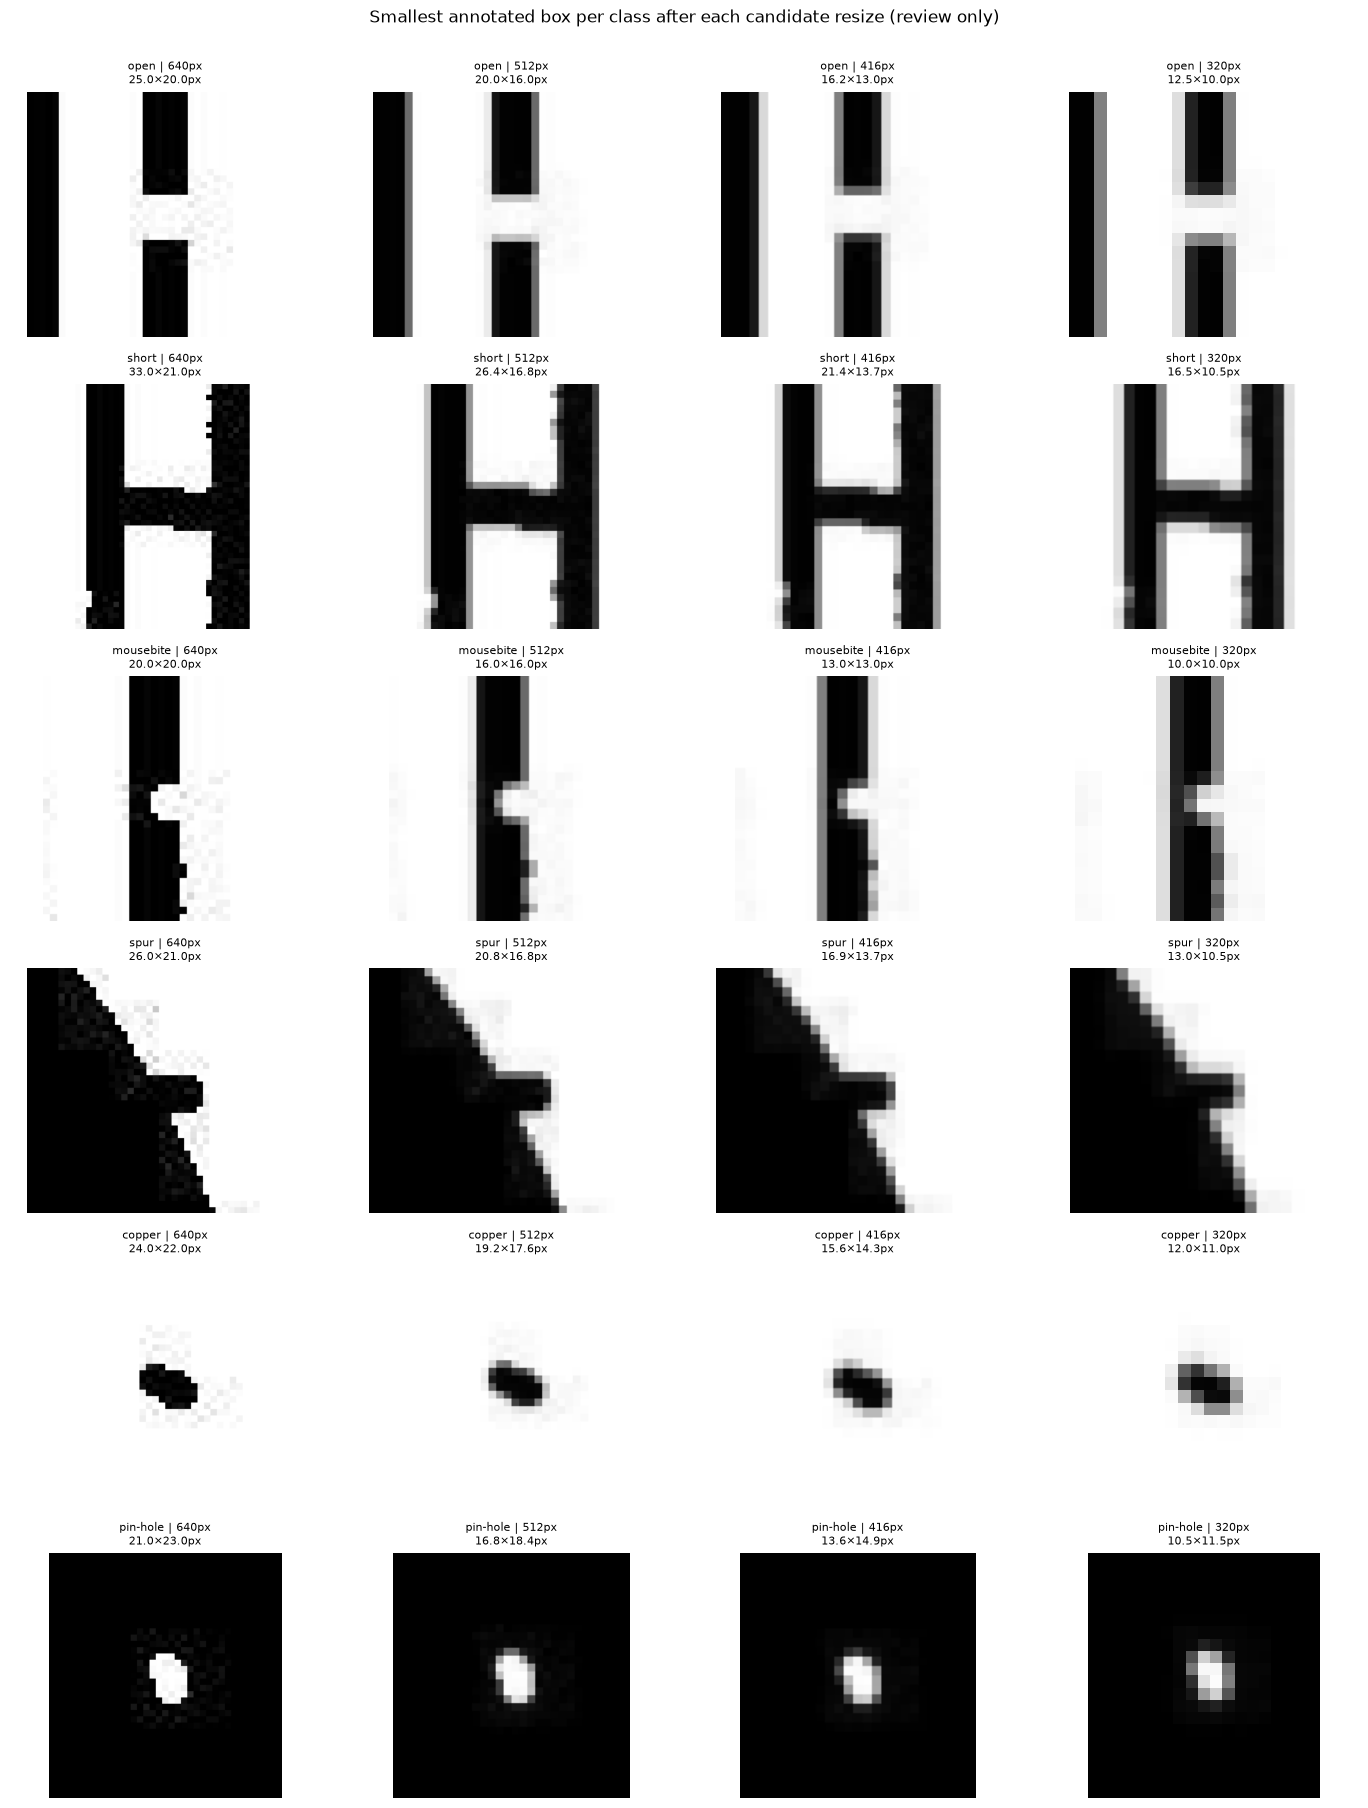

This audit cannot select the final detector input size by AP/recall. Keep 640 as the accuracy-first baseline; use validation detector results to decide whether a smaller size is acceptable.


In [10]:
import time

INPUT_SIZE_CANDIDATES = (640, 512, 416, 320)
box_sizes = source_targets[[
    "split", "image_name", "class_index", "class_name",
    "x1", "y1", "x2", "y2", "image_width", "image_height",
]].copy()
box_sizes["source_width_px"] = box_sizes["x2"] - box_sizes["x1"]
box_sizes["source_height_px"] = box_sizes["y2"] - box_sizes["y1"]
box_sizes["width_norm"] = box_sizes["source_width_px"] / box_sizes["image_width"]
box_sizes["height_norm"] = box_sizes["source_height_px"] / box_sizes["image_height"]

size_audit_rows = []
class_size_rows = []
for input_size in INPUT_SIZE_CANDIDATES:
    scaled_width = box_sizes["width_norm"] * input_size
    scaled_height = box_sizes["height_norm"] * input_size
    min_side = np.minimum(scaled_width, scaled_height)
    size_audit_rows.append({
        "input_size": input_size,
        "p05_box_w_px": scaled_width.quantile(0.05),
        "p05_box_h_px": scaled_height.quantile(0.05),
        "median_box_w_px": scaled_width.median(),
        "median_box_h_px": scaled_height.median(),
        "p05_box_w_cells_s8": scaled_width.quantile(0.05) / 8,
        "p05_box_h_cells_s8": scaled_height.quantile(0.05) / 8,
        "pct_boxes_min_side_lt_8px": 100 * min_side.lt(8).mean(),
        "pct_boxes_min_side_lt_16px": 100 * min_side.lt(16).mean(),
        "one_image_float32_mib": input_size * input_size * 3 * 4 / (1024 ** 2),
        "pixels_vs_640_pct": 100 * (input_size / 640) ** 2,
    })
    for class_index, class_name in enumerate(CLASS_NAMES):
        class_mask = box_sizes["class_index"].eq(class_index)
        class_min_side = min_side[class_mask]
        class_size_rows.append({
            "input_size": input_size,
            "class_name": class_name,
            "boxes": int(class_mask.sum()),
            "median_min_side_px": class_min_side.median(),
            "pct_min_side_lt_8px": 100 * class_min_side.lt(8).mean(),
            "pct_min_side_lt_16px": 100 * class_min_side.lt(16).mean(),
        })

size_audit = pd.DataFrame(size_audit_rows)
class_size_audit = pd.DataFrame(class_size_rows)
print("Dataset-only size audit. Feature-stride columns describe sampling grid, not detector AP.")
display(size_audit.round(2))
print("Per-class fraction with minimum bbox side below 8 pixels:")
display(class_size_audit.pivot(
    index="class_name", columns="input_size", values="pct_min_side_lt_8px"
).reindex(CLASS_NAMES).round(1).rename_axis(columns="input_size: percent < 8 px"))
print("Per-class fraction with minimum bbox side below 16 pixels:")
display(class_size_audit.pivot(
    index="class_name", columns="input_size", values="pct_min_side_lt_16px"
).reindex(CLASS_NAMES).round(1).rename_axis(columns="input_size: percent < 16 px"))

SIZE_BENCHMARK_SAMPLE_COUNT = min(48, len(image_manifest))
benchmark_images = image_manifest.sample(
    n=SIZE_BENCHMARK_SAMPLE_COUNT, random_state=RANDOM_SEED
)
resize_timing_rows = []
for input_size in INPUT_SIZE_CANDIDATES:
    mode = "none" if input_size == 640 else "resize"
    started_at = time.perf_counter()
    for row in benchmark_images.itertuples():
        row_boxes = source_targets.loc[
            (source_targets["split"] == row.split)
            & (source_targets["image_name"] == row.image_name)
        ].to_dict("records")
        preprocess_image_and_boxes(
            row.image_path, row_boxes, spatial_mode=mode, target_size=input_size
        )
    elapsed_seconds = time.perf_counter() - started_at
    resize_timing_rows.append({
        "input_size": input_size,
        "images_timed": SIZE_BENCHMARK_SAMPLE_COUNT,
        "decode_transform_ms_per_image": 1000 * elapsed_seconds / SIZE_BENCHMARK_SAMPLE_COUNT,
    })
print("CPU decode + preprocessing time on a fixed random image sample; not model inference latency:")
display(pd.DataFrame(resize_timing_rows).round(2))

smallest_box_rows = []
for class_index, class_name in enumerate(CLASS_NAMES):
    class_candidates = box_sizes.loc[box_sizes["class_index"] == class_index].copy()
    class_candidates["area_px"] = class_candidates["source_width_px"] * class_candidates["source_height_px"]
    smallest_box_rows.append(class_candidates.sort_values("area_px").iloc[0])

figure, axes = plt.subplots(len(CLASS_NAMES), len(INPUT_SIZE_CANDIDATES), figsize=(14, 18))
for row_index, sample in enumerate(smallest_box_rows):
    source_image_row = image_manifest.loc[
        (image_manifest["split"] == sample["split"])
        & (image_manifest["image_name"] == sample["image_name"])
    ].iloc[0]
    source_image_boxes = source_targets.loc[
        (source_targets["split"] == sample["split"])
        & (source_targets["image_name"] == sample["image_name"])
    ].to_dict("records")
    box_index = next(
        index for index, candidate in enumerate(source_image_boxes)
        if candidate["class_index"] == sample["class_index"]
        and candidate["x1"] == sample["x1"]
        and candidate["y1"] == sample["y1"]
        and candidate["x2"] == sample["x2"]
        and candidate["y2"] == sample["y2"]
    )
    for column_index, input_size in enumerate(INPUT_SIZE_CANDIDATES):
        mode = "none" if input_size == 640 else "resize"
        transformed_image, transformed_boxes, _ = preprocess_image_and_boxes(
            source_image_row["image_path"],
            source_image_boxes,
            spatial_mode=mode,
            target_size=input_size,
        )
        box = transformed_boxes[box_index]
        padding = max(4, int(round(0.35 * max(box["x2"] - box["x1"], box["y2"] - box["y1"]))))
        left = max(0, int(np.floor(box["x1"] - padding)))
        top = max(0, int(np.floor(box["y1"] - padding)))
        right = min(input_size, int(np.ceil(box["x2"] + padding)))
        bottom = min(input_size, int(np.ceil(box["y2"] + padding)))
        crop = transformed_image.crop((left, top, right, bottom))
        crop = crop.resize((crop.width * 4, crop.height * 4), Image.Resampling.NEAREST)
        axes[row_index, column_index].imshow(crop)
        axes[row_index, column_index].set_title(
            f"{CLASS_NAMES[int(sample['class_index'])]} | {input_size}px\n"
            f"{box['x2'] - box['x1']:.1f}×{box['y2'] - box['y1']:.1f}px",
            fontsize=8,
        )
        axes[row_index, column_index].axis("off")
figure.suptitle("Smallest annotated box per class after each candidate resize (review only)", y=1.002)
figure.tight_layout()
plt.show()

print(
    "This audit cannot select the final detector input size by AP/recall. "
    "Keep 640 as the accuracy-first baseline; use validation detector results to decide whether a smaller size is acceptable."
)

### Quyết định tạm thời

Dùng `resize/512` cho lượt huấn luyện đầu: so với 640, tensor float32/ảnh giảm 36%; chỉ khoảng 0,02% box có cạnh ngắn dưới 16 px, trong khi tỷ lệ này tăng lên 4,09% ở 416 và 55,69% ở 320. Giữ `none/640` làm reference. Đây là lựa chọn kỹ thuật để bắt đầu, không phải size tối ưu AP; cần xác nhận bằng detector validation. Luôn train trên full board với bbox. Chỉ cân nhắc tiling chồng lấn nếu recall defect nhỏ kém; không crop riêng từng bbox.

## 3. Materialize processed dataset

Giữ nguyên cây `train/valid/test`, xuất cả ảnh không annotation và file label rỗng nếu có. Ghi canonical bbox theo pixel cùng nhãn YOLO normalized. Mean/std RGB là thống kê pooled từ pixel train sau transform; validation/test không tham gia fit normalization.

In [14]:
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
image_stems = list(zip(image_manifest["split"], image_manifest["image_name"].map(lambda name: Path(name).stem)))
if len(set(image_stems)) != len(image_stems):
    raise ValueError("Image stems must be unique within each split for YOLO label export")

class_mapping.to_csv(OUTPUT_ROOT / "class_mapping.csv", index=False)
targets_by_image = {
    key: rows.sort_values(["class_index", "y1", "x1"])
    for key, rows in source_targets.groupby(["split", "image_name"], sort=False)
}
processed_image_rows = []
processed_target_rows = []
train_pixel_sum = np.zeros(3, dtype=np.float64)
train_pixel_squared_sum = np.zeros(3, dtype=np.float64)
train_pixel_count = 0

for image_row in image_manifest.itertuples():
    image_key = (image_row.split, image_row.image_name)
    image_targets = targets_by_image.get(image_key)
    target_records = [] if image_targets is None else image_targets.to_dict("records")
    processed_image, transformed_boxes, transform_metadata = preprocess_image_and_boxes(
        image_row.image_path,
        target_records,
        spatial_mode=SPATIAL_MODE,
        target_size=TARGET_SIZE,
    )

    if SPATIAL_MODE == "none":
        output_image_name = image_row.image_name
    else:
        output_image_name = f"{Path(image_row.image_name).stem}.png"
    processed_image_path = OUTPUT_ROOT / image_row.split / "images" / output_image_name
    processed_image_path.parent.mkdir(parents=True, exist_ok=True)
    if SPATIAL_MODE == "none":
        shutil.copy2(image_row.image_path, processed_image_path)
    else:
        processed_image.save(processed_image_path, format="PNG", optimize=False)

    float_image = image_to_float01(processed_image)
    if image_row.split == "train":
        train_pixel_sum += float_image.sum(axis=(0, 1), dtype=np.float64)
        train_pixel_squared_sum += np.square(float_image, dtype=np.float64).sum(axis=(0, 1))
        train_pixel_count += float_image.shape[0] * float_image.shape[1]

    label_output_path = OUTPUT_ROOT / image_row.split / "labels" / f"{Path(output_image_name).stem}.txt"
    label_output_path.parent.mkdir(parents=True, exist_ok=True)
    yolo_lines = []
    for box in transformed_boxes:
        box_width = box["x2"] - box["x1"]
        box_height = box["y2"] - box["y1"]
        center_x = (box["x1"] + box["x2"]) / 2
        center_y = (box["y1"] + box["y2"]) / 2
        normalized_center_x = center_x / transform_metadata["output_width"]
        normalized_center_y = center_y / transform_metadata["output_height"]
        normalized_width = box_width / transform_metadata["output_width"]
        normalized_height = box_height / transform_metadata["output_height"]
        yolo_lines.append(
            f"{int(box['class_index'])} {normalized_center_x:.8f} "
            f"{normalized_center_y:.8f} {normalized_width:.8f} "
            f"{normalized_height:.8f}"
        )
        processed_target_rows.append({
            "split": image_row.split,
            "image_name": output_image_name,
            "class_id": int(box["class_id"]),
            "class_index": int(box["class_index"]),
            "class_name": box["class_name"],
            "x1": box["x1"],
            "y1": box["y1"],
            "x2": box["x2"],
            "y2": box["y2"],
            "image_width": transform_metadata["output_width"],
            "image_height": transform_metadata["output_height"],
            "x_center_norm": normalized_center_x,
            "y_center_norm": normalized_center_y,
            "width_norm": normalized_width,
            "height_norm": normalized_height,
        })
    label_output_path.write_text(
        "\n".join(yolo_lines) + ("\n" if yolo_lines else ""),
        encoding="utf-8",
    )

    processed_image_rows.append({
        "split": image_row.split,
        "image_name": output_image_name,
        "image_path": (Path(image_row.split) / "images" / output_image_name).as_posix(),
        "label_path": (Path(image_row.split) / "labels" / label_output_path.name).as_posix(),
        "source_image_name": image_row.image_name,
        "source_width": image_row.source_width,
        "source_height": image_row.source_height,
        "source_mode": image_row.source_mode,
        "output_width": transform_metadata["output_width"],
        "output_height": transform_metadata["output_height"],
        "scale_x": transform_metadata["scale_x"],
        "scale_y": transform_metadata["scale_y"],
        "offset_x": transform_metadata["offset_x"],
        "offset_y": transform_metadata["offset_y"],
        "num_boxes": len(transformed_boxes),
    })

if train_pixel_count == 0:
    raise ValueError("No train pixels available to calculate normalization statistics")
train_pixel_mean = train_pixel_sum / train_pixel_count
train_pixel_variance = np.maximum(
    train_pixel_squared_sum / train_pixel_count - train_pixel_mean ** 2,
    0.0,
)
train_pixel_std = np.sqrt(train_pixel_variance)
processed_manifest = pd.DataFrame(processed_image_rows)
processed_targets = pd.DataFrame(processed_target_rows, columns=[
    "split", "image_name", "class_id", "class_index", "class_name",
    "x1", "y1", "x2", "y2", "image_width", "image_height",
    "x_center_norm", "y_center_norm", "width_norm", "height_norm",
]).sort_values(["split", "image_name", "class_index", "y1", "x1"]).reset_index(drop=True)

processed_manifest.to_csv(OUTPUT_ROOT / "image_manifest.csv", index=False)
processed_targets.to_csv(OUTPUT_ROOT / "annotations_xyxy.csv", index=False)
normalization_stats = {
    "computed_from_split": "train",
    "pixel_scale": "RGB uint8 / 255.0",
    "channel_order": "RGB",
    "mean": train_pixel_mean.tolist(),
    "std": train_pixel_std.tolist(),
    "pixel_count": int(train_pixel_count),
}
with (OUTPUT_ROOT / "normalization.json").open("w", encoding="utf-8") as output_file:
    json.dump(normalization_stats, output_file, indent=2)

preprocessing_config = {
    "spatial_mode": SPATIAL_MODE,
    "target_size": TARGET_SIZE,
    "letterbox_pad_value": PAD_VALUE,
    "interpolation": "bilinear",
    "source_data_root": display_path(DATA_ROOT),
    "source_targets": display_path(TARGETS_CSV),
    "output_root": display_path(OUTPUT_ROOT),
    "random_seed": RANDOM_SEED,
    "augmentation_applied": False,
    "raw_images_modified": False,
    "python_and_package_versions": package_versions,
}
with (OUTPUT_ROOT / "preprocessing_config.json").open("w", encoding="utf-8") as output_file:
    json.dump(preprocessing_config, output_file, indent=2)

names_yaml = "\n".join(
    f"  {int(row.class_index)}: {row.class_name}"
    for row in class_mapping.itertuples(index=False)
)
yolo_data_yaml = (
    "path: .\n"
    "train: train/images\n"
    "val: valid/images\n"
    "test: test/images\n"
    f"names:\n{names_yaml}\n"
)
(OUTPUT_ROOT / "data.yaml").write_text(yolo_data_yaml, encoding="utf-8")

print(f"Processed images: {len(processed_manifest):,} | processed bbox rows: {len(processed_targets):,}")
print("Train-derived RGB normalization stats:")
display(pd.DataFrame({"channel": ["R", "G", "B"], "mean": train_pixel_mean, "std": train_pixel_std}).set_index("channel").round(6))
print("Created artifacts:")
for artifact_name in (
    "image_manifest.csv", "annotations_xyxy.csv", "class_mapping.csv",
    "normalization.json", "preprocessing_config.json", "data.yaml",
):
    print(f"- {display_path(OUTPUT_ROOT / artifact_name)}")

Processed images: 1,500 | processed bbox rows: 10,013
Train-derived RGB normalization stats:


,mean,std
channel,,
R,0.651605,0.469019
G,0.651613,0.469017
B,0.651605,0.469019


Created artifacts:
- Data/processed/resize_512/image_manifest.csv
- Data/processed/resize_512/annotations_xyxy.csv
- Data/processed/resize_512/class_mapping.csv
- Data/processed/resize_512/normalization.json
- Data/processed/resize_512/preprocessing_config.json
- Data/processed/resize_512/data.yaml


## 4. Kiểm tra output và overlay

Xác minh số ảnh/nhãn, class IDs, tọa độ, khả năng đọc ảnh và tương đương byte khi giữ nguyên ảnh. Gallery đặt ảnh nguồn và ảnh processed cạnh nhau với bbox tương ứng cho một mẫu mỗi split. Đây là regression/sanity check, không thay thế rà soát nhãn toàn bộ dữ liệu.

Validated 1,500 processed images, 10,013 YOLO rows, and 10,013 canonical bbox rows.


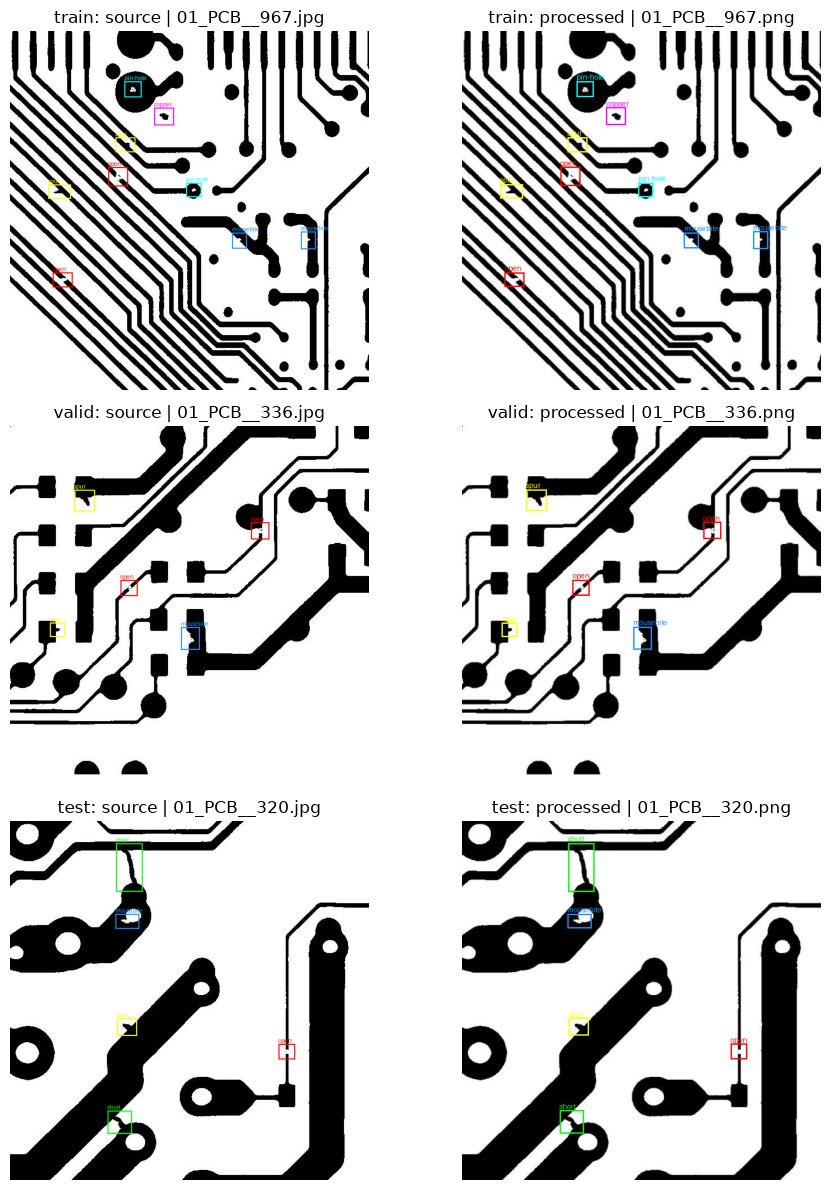

In [15]:
import hashlib

processed_manifest_path = OUTPUT_ROOT / "image_manifest.csv"
processed_targets_path = OUTPUT_ROOT / "annotations_xyxy.csv"
processed_manifest_roundtrip = pd.read_csv(processed_manifest_path)
processed_targets_roundtrip = pd.read_csv(processed_targets_path)
if len(processed_manifest_roundtrip) != len(image_manifest):
    raise ValueError("Processed image manifest row count differs from the source inventory")
if len(processed_targets_roundtrip) != len(source_targets):
    raise ValueError("Processed bbox row count differs from the canonical input")

processed_key_set = set(zip(
    processed_manifest_roundtrip["split"],
    processed_manifest_roundtrip["image_name"],
))
expected_key_set = set(zip(
    image_manifest["split"],
    image_manifest["image_name"].map(
        lambda name: name if SPATIAL_MODE == "none" else f"{Path(name).stem}.png"
    ),
))
if processed_key_set != expected_key_set:
    raise ValueError("Processed manifest image keys differ from the expected split inventory")

processed_box_count = 0
image_dimensions_checked = 0
for output_row in processed_manifest_roundtrip.itertuples(index=False):
    image_path = OUTPUT_ROOT / output_row.image_path
    label_path = OUTPUT_ROOT / output_row.label_path
    if not image_path.is_file() or not label_path.is_file():
        raise FileNotFoundError(f"Missing processed image or label for {output_row.image_name}")
    with Image.open(image_path) as image:
        image.load()
        if image.size != (int(output_row.output_width), int(output_row.output_height)):
            raise ValueError(f"Output dimensions mismatch for {output_row.image_name}")
    image_dimensions_checked += 1

    source_key = (output_row.split, output_row.source_image_name)
    if SPATIAL_MODE == "none":
        source_path = image_path_by_key[source_key]
        source_hash = hashlib.sha256(source_path.read_bytes()).digest()
        output_hash = hashlib.sha256(image_path.read_bytes()).digest()
        if source_hash != output_hash:
            raise ValueError(f"Raw image bytes changed for {output_row.source_image_name}")

    for line_number, line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), start=1):
        fields = line.split()
        if len(fields) != 5:
            raise ValueError(f"Expected 5 YOLO fields in {display_path(label_path)}:{line_number}")
        class_index = int(fields[0])
        values = np.asarray(fields[1:], dtype=float)
        if not 0 <= class_index < len(CLASS_NAMES):
            raise ValueError(f"Unknown class index in {display_path(label_path)}:{line_number}")
        if not np.isfinite(values).all() or np.any((values < 0) | (values > 1)):
            raise ValueError(f"Invalid normalized YOLO coordinates in {display_path(label_path)}:{line_number}")
        if values[2] <= 0 or values[3] <= 0:
            raise ValueError(f"Non-positive normalized box size in {display_path(label_path)}:{line_number}")
        processed_box_count += 1

if processed_box_count != len(processed_targets_roundtrip):
    raise ValueError("YOLO row count differs from the pixel-coordinate annotation CSV")

if SPATIAL_MODE == "none":
    identity_sort_columns = [
        "split", "image_name", "class_index", "class_id", "class_name",
        "y1", "x1", "y2", "x2",
    ]
    source_identity = source_targets.sort_values(identity_sort_columns).reset_index(drop=True)
    processed_identity = processed_targets_roundtrip.sort_values(identity_sort_columns).reset_index(drop=True)
    identity_columns = ["split", "image_name", "class_id", "class_index", "class_name"]
    if not source_identity[identity_columns].equals(processed_identity[identity_columns]):
        raise ValueError("Source and processed annotation identities differ")
    for coordinate in ("x1", "y1", "x2", "y2"):
        if not np.array_equal(
            source_identity[coordinate].to_numpy(dtype=float),
            processed_identity[coordinate].to_numpy(dtype=float),
        ):
            raise ValueError(f"{coordinate} changed in no-resize mode")

print(
    f"Validated {image_dimensions_checked:,} processed images, "
    f"{processed_box_count:,} YOLO rows, and "
    f"{len(processed_targets_roundtrip):,} canonical bbox rows."
)
if SPATIAL_MODE == "none":
    print("Raw-to-processed SHA-256 and source bbox coordinates match exactly.")


def draw_review_boxes(image, boxes):
    preview = image.convert("RGB")
    draw = ImageDraw.Draw(preview)
    palette = ["red", "lime", "dodgerblue", "yellow", "magenta", "cyan"]
    for box in boxes.itertuples(index=False):
        color = palette[int(box.class_index) % len(palette)]
        draw.rectangle((box.x1, box.y1, box.x2, box.y2), outline=color, width=2)
        draw.text((box.x1, max(0, box.y1 - 12)), str(box.class_name), fill=color)
    return preview


figure, axes = plt.subplots(len(SPLITS), 2, figsize=(10, 4 * len(SPLITS)), squeeze=False)
for row_index, split in enumerate(SPLITS):
    split_images = image_manifest.loc[
        (image_manifest["split"] == split) & (image_manifest["num_boxes"] > 0)
    ]
    sample_image = split_images.sample(n=1, random_state=RANDOM_SEED).iloc[0]
    source_boxes = source_targets.loc[
        (source_targets["split"] == split)
        & (source_targets["image_name"] == sample_image["image_name"])
    ]
    output_name = (
        sample_image["image_name"]
        if SPATIAL_MODE == "none"
        else f"{Path(sample_image['image_name']).stem}.png"
    )
    processed_boxes = processed_targets_roundtrip.loc[
        (processed_targets_roundtrip["split"] == split)
        & (processed_targets_roundtrip["image_name"] == output_name)
    ]
    with Image.open(sample_image["image_path"]) as source_image:
        axes[row_index, 0].imshow(draw_review_boxes(source_image, source_boxes))
    processed_image_path = OUTPUT_ROOT / split / "images" / output_name
    with Image.open(processed_image_path) as output_image:
        axes[row_index, 1].imshow(draw_review_boxes(output_image, processed_boxes))
    axes[row_index, 0].set_title(f"{split}: source | {sample_image['image_name']}")
    axes[row_index, 1].set_title(f"{split}: processed | {output_name}")
    axes[row_index, 0].axis("off")
    axes[row_index, 1].axis("off")
figure.tight_layout()
plt.show()

In [16]:
for manifest_row in processed_manifest_roundtrip.itertuples(index=False):
    target_rows = processed_targets_roundtrip.loc[
        (processed_targets_roundtrip["split"] == manifest_row.split)
        & (processed_targets_roundtrip["image_name"] == manifest_row.image_name)
    ]
    label_path = OUTPUT_ROOT / manifest_row.label_path
    label_lines = label_path.read_text(encoding="utf-8").splitlines()
    if len(label_lines) != len(target_rows):
        raise ValueError(f"CSV/YOLO annotation count mismatch for {manifest_row.image_name}")
    for target_row, label_line in zip(target_rows.itertuples(index=False), label_lines):
        fields = label_line.split()
        actual_class_index = int(fields[0])
        actual_values = np.asarray(fields[1:], dtype=float)
        expected_values = np.asarray([
            target_row.x_center_norm,
            target_row.y_center_norm,
            target_row.width_norm,
            target_row.height_norm,
        ], dtype=float)
        if actual_class_index != int(target_row.class_index):
            raise ValueError(f"Class ID mismatch between CSV and YOLO for {manifest_row.image_name}")
        if not np.allclose(actual_values, expected_values, rtol=0, atol=1e-7):
            raise ValueError(f"Coordinate mismatch between CSV and YOLO for {manifest_row.image_name}")

with (OUTPUT_ROOT / "normalization.json").open(encoding="utf-8") as input_file:
    saved_normalization = json.load(input_file)
if saved_normalization["computed_from_split"] != "train":
    raise ValueError("Normalization statistics must be computed from train only")
if not np.isfinite(saved_normalization["mean"] + saved_normalization["std"]).all():
    raise ValueError("Normalization statistics contain non-finite values")
if np.any(np.asarray(saved_normalization["std"]) <= 0):
    raise ValueError("Normalization standard deviations must be positive")
yolo_dataset_config = (OUTPUT_ROOT / "data.yaml").read_text(encoding="utf-8")
for required_entry in ("train: train/images", "val: valid/images", "test: test/images"):
    if required_entry not in yolo_dataset_config:
        raise ValueError(f"YOLO data config is missing {required_entry!r}")
print("CSV/YOLO row-level equivalence, train-only normalization, and YOLO split config passed.")

CSV/YOLO row-level equivalence, train-only normalization, and YOLO split config passed.
